This notebook trains an XGBoost Regressor to predict the next-day closing price of Bitcoin (BTC-USD) using features engineered from historical OHLCV (Open, High, Low, Close, Volume) data — including rolling averages and price ratios across multiple time horizons. Hyperparameters such as learning rate, max depth and subsampling ratio are tuned with RandomizedSearchCV using time-series cross-validation.

In [1]:
!pip install xgboost
!pip install yfinance

In [2]:
import yfinance as yf
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import xgboost as xgb
import pickle

In [3]:
btc_ticker = yf.Ticker("BTC-USD")
if os.path.exists("btc.csv"):
    btc = pd.read_csv("btc.csv", index_col=0)
else:
    btc = btc_ticker.history(start="2014-09-17", end="2024-09-01")
    btc.to_csv("btc.csv")

In [4]:
btc = btc.drop(columns=["Dividends", "Stock Splits"])
btc.index = pd.to_datetime(btc.index)
btc.index = btc.index.tz_localize(None)

In [5]:
def compute_rolling(btc):
    horizons = [2,7,60,365]

    for horizon in horizons:
        rolling_averages = btc.rolling(horizon, min_periods=1).mean()

        ratio_column = f"open_ratio_{horizon}"
        btc[ratio_column] = btc["Open"] / rolling_averages["Open"]

        rolling = btc.rolling(horizon, closed='left', min_periods=1).mean()
        trend_column = f"trend_{horizon}"
        btc[trend_column] = rolling["Open"]

        btc = btc.dropna()

    return btc

In [6]:
btc = compute_rolling(btc)
# btc.fillna(method='ffill', inplace=True)

/tmp/ipykernel_2574/1502108625.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc[ratio_column] = btc["Open"] / rolling_averages["Open"]
/tmp/ipykernel_2574/1502108625.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc[trend_column] = rolling["Open"]


In [7]:
btc_features = ['Open', 'High', 'Low', 'Volume', 'open_ratio_2', 'trend_2', 'open_ratio_7', 'trend_7', 'open_ratio_60', 'trend_60', 'open_ratio_365', 'trend_365']
X = btc[btc_features]
y = btc['Close']

In [8]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
train_len = int(len(X) * 0.8)

X_train, X_test = X_scaled[0:train_len], X_scaled[train_len:len(X)]
y_train, y_test = y[0:train_len], y[train_len:len(X)]

In [10]:
# Set up the hyperparameter grid for RandomizedSearchCV
parameters = {
    'n_estimators': [50, 100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Initialize the XGBoost model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror')

tscv = TimeSeriesSplit(n_splits=3)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=parameters, n_iter=200, cv=tscv, verbose=1,
                                   scoring='neg_mean_squared_error', n_jobs=-1, random_state=1)

random_search.fit(X_train, y_train)
best_xgb = random_search.best_estimator_

# Make predictions
y_pred = best_xgb.predict(X_test)

Fitting 3 folds for each of 200 candidates, totalling 600 fits


In [11]:
best_xgb_params = best_xgb.get_params()
print(best_xgb_params)

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.6, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.2, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.6, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [12]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"XGB - Mean Absolute Error: {mae}")
print(f"XGB - Mean Squared Error: {mse}")
print(f"XGB - Root Mean Squared Error: {rmse}")
print(f"XGB - R^2 Score: {r2}")

XGB - Mean Absolute Error: 1136.7238799754987
XGB - Mean Squared Error: 3486444.313582095
XGB - Root Mean Squared Error: 1867.2022690598078
XGB - R^2 Score: 0.988845293511402


In [13]:
# Reshape y_test and y_pred to 2D arrays for the scaler
y_test_reshaped = np.array(y_test).reshape(-1, 1)
y_pred_reshaped = np.array(y_pred).reshape(-1, 1)

# Min-Max scale y_test and y_pred
scaler = StandardScaler()
y_test_scaled = scaler.fit_transform(y_test_reshaped)
y_pred_scaled = scaler.transform(y_pred_reshaped)

# Calculate the metrics on the scaled data
mae_scaled_rf = mean_absolute_error(y_test_scaled, y_pred_scaled)
mse_scaled_rf = mean_squared_error(y_test_scaled, y_pred_scaled)
rmse_scaled_rf = np.sqrt(mse_scaled_rf)
r2_scaled_rf = r2_score(y_test_scaled, y_pred_scaled)

print(f"XGB - Scaled Mean Absolute Error: {mae_scaled_rf}")
print(f"XGB - Scaled Mean Squared Error: {mse_scaled_rf}")
print(f"XGB - Scaled Root Mean Squared Error: {rmse_scaled_rf}")
print(f"XGB - Scaled R^2: {r2_scaled_rf}")

XGB - Scaled Mean Absolute Error: 0.06429729043605832
XGB - Scaled Mean Squared Error: 0.011154706908700804
XGB - Scaled Root Mean Squared Error: 0.10561584591670325
XGB - Scaled R^2: 0.9888452930912992


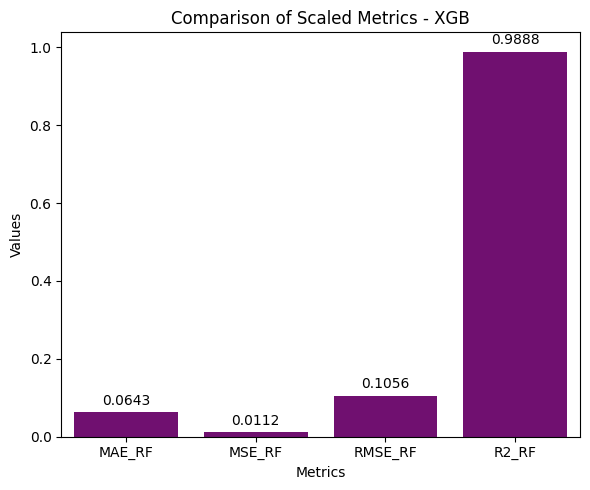

In [14]:
# Prepare data for plotting
metrics = ['MAE_RF', 'MSE_RF', 'RMSE_RF', 'R2_RF']
scaled_values = [mae_scaled_rf, mse_scaled_rf, rmse_scaled_rf, r2_scaled_rf]

# Create a DataFrame for better visualization with Seaborn
metrics_df = pd.DataFrame({'Metric': metrics, 'Value': scaled_values})

# Plotting the scaled metrics using seaborn
plt.figure(figsize=(6, 5))
sns.barplot(x='Metric', y='Value', data=metrics_df, color="purple")

# Add some text for labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Comparison of Scaled Metrics - XGB')

# Function to label the bars
def autolabel(rects, ax):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 4)),  # rounded to 4 decimal places for better precision
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Get the current Axes instance
ax = plt.gca()

# Apply the autolabel function
rects = ax.patches
autolabel(rects, ax)

plt.tight_layout()
plt.show()

In [15]:
print(y_test[30:])

Date
2022-10-05    20160.716797
2022-10-06    19955.443359
2022-10-07    19546.849609
2022-10-08    19416.568359
2022-10-09    19446.425781
                  ...     
2024-08-27    59504.132812
2024-08-28    59027.625000
2024-08-29    59388.179688
2024-08-30    59119.476562
2024-08-31    58969.898438
Name: Close, Length: 697, dtype: float64


Date
2022-09-05    19711.148438
2022-09-06    19682.230469
2022-09-07    19587.861328
2022-09-08    19501.013672
2022-09-09    20428.373047
                  ...     
2024-08-27    60347.277344
2024-08-28    58074.136719
2024-08-29    58844.007812
2024-08-30    58582.515625
2024-08-31    58500.187500
Length: 727, dtype: float32


Text(0.5, 0, 'Date')

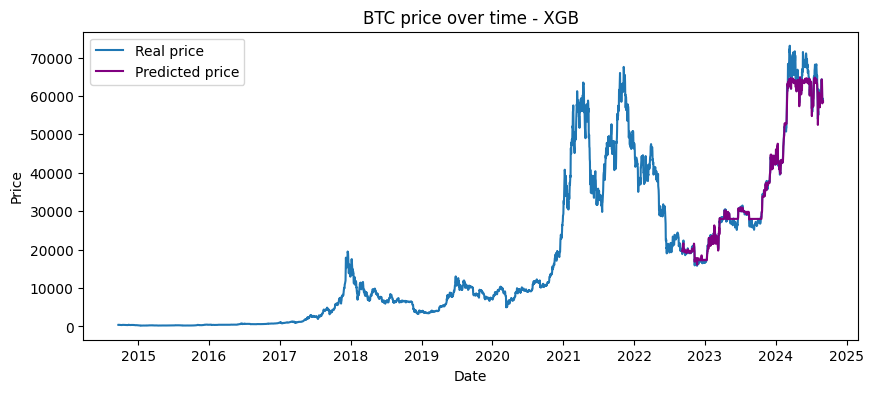

In [16]:
y_pred = pd.Series(y_pred, index=y_test.index)
# y_pred = y_pred.sort_index()
print(y_pred)

plt.figure(figsize=(10,4))

# Add title
plt.title("BTC price over time - XGB")

# Line chart
sns.lineplot(data=btc["Close"], label="Real price")

# Line chart
sns.lineplot(data=y_pred, label="Predicted price", color="purple")

# Add legend
plt.legend()

# Add label for vertical axis
plt.ylabel("Price")

# Add label for horizontal axis
plt.xlabel("Date")

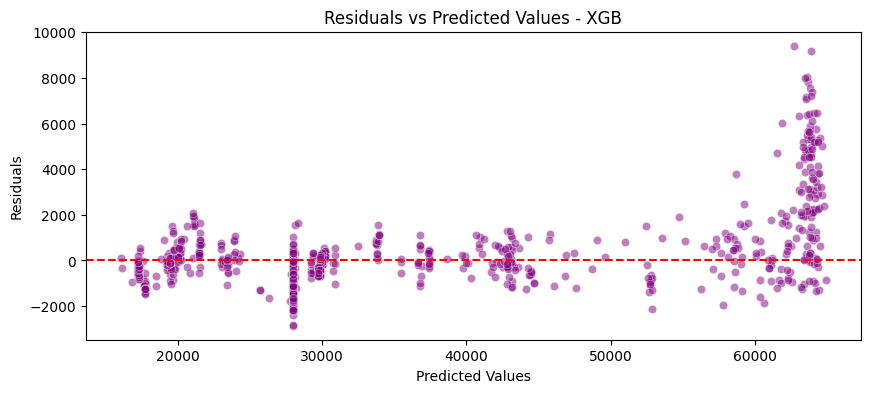

In [17]:
# Calculate residuals
residuals = y_test - y_pred

# Plot residuals using seaborn
plt.figure(figsize=(10, 4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color="purple")
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values - XGB')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

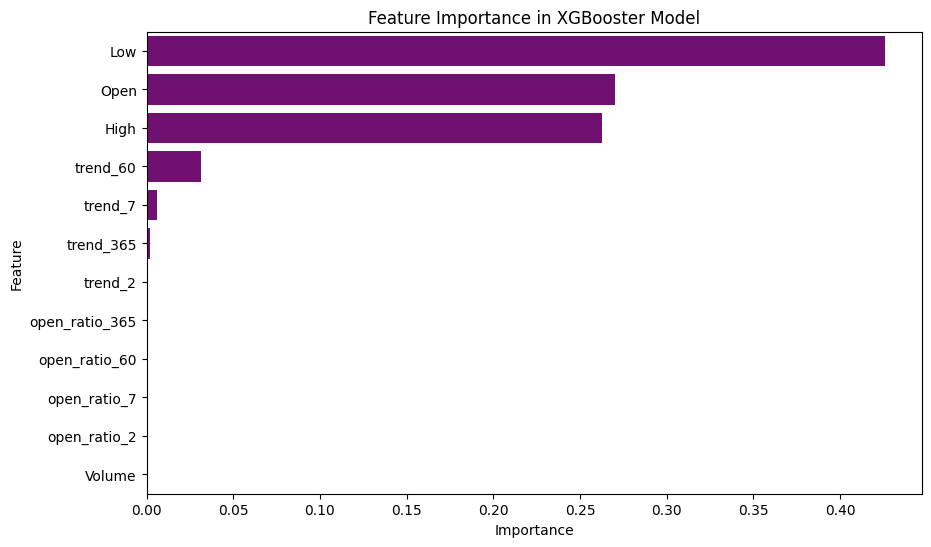

In [18]:
# Get feature importances from the best model
importances = best_xgb.feature_importances_

# Create a DataFrame for better visualization
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, color="purple")
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in XGBooster Model')
plt.show()

In [19]:
compare = pd.DataFrame({'y_test': y_test, 'y_pred_xgb': y_pred}, index=y_test.index)
compare

,y_test,y_pred_xgb
Date,,
2022-09-05,19812.371094,19711.148438
2022-09-06,18837.667969,19682.230469
2022-09-07,19290.324219,19587.861328
2022-09-08,19329.833984,19501.013672
2022-09-09,21381.152344,20428.373047
...,...,...
2024-08-27,59504.132812,60347.277344
2024-08-28,59027.625000,58074.136719
2024-08-29,59388.179688,58844.007812


In [20]:
# Save the Series to files

with open('scaled_values_xgb.pkl', 'wb') as f:
    pickle.dump(scaled_values, f)
with open('y_pred_xgb.pkl', 'wb') as f:
    pickle.dump(y_pred, f)
with open('residuals_xgb.pkl', 'wb') as f:
    pickle.dump(residuals, f)